# 01 · Exploration

Profiling the raw transaction file **before** anything is cleaned, so every
decision in notebook 02 can point at a number here.

The dataset is 60,154 transactions across 3,000 accounts over 12 months, with a
small number of planted laundering patterns. The ground-truth labels are *not*
opened in this notebook.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent / "src"))
import warnings; warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import config

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 30)
plt.rcParams.update({"figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
                     "axes.edgecolor": "#e3e2dc", "grid.color": "#e3e2dc",
                     "axes.titleweight": "bold", "figure.dpi": 110,
                     "axes.spines.top": False, "axes.spines.right": False})
S1, S2, S3 = "#2a78d6", "#eb6834", "#1baf7a"

In [2]:
df = pd.read_csv(config.RAW_TRANSACTIONS)
print(f"{len(df):,} rows x {df.shape[1]} columns")
df.head()

60,154 rows x 10 columns


,transaction_id,timestamp,sender_account,receiver_account,amount,currency,sender_country,receiver_country,transaction_type,channel
0,TXN0050807,2025-02-23 10:08:51,ACC100662,ACC101604,94.08,GBP,United Kingdom,Ireland,withdrawal,atm_withdrawal
1,TXN0035695,2025-03-26 21:12:53,ACC101715,ACC101949,128.67,GBP,Netherlands,Germany,transfer,online_transfer
2,TXN0010835,2025-07-29 10:02:25,ACC100025,ACC100677,44.24,GBP,France,Ireland,payment,online_transfer
3,TXN0031111,2025-03-08 10:40:21,ACC102280,ACC101281,178.79,GBP,United Kingdom,Spain,transfer,online_transfer
4,TXN0034912,2025-07-23 20:03:18,ACC102012,ACC100726,41.01,GBP,United Kingdom,United Kingdom,payment,mobile_app


## Completeness

Three columns have gaps. None of them is the transaction amount for most rows, but 60 rows are unscoreable.

In [3]:
missing = df.isna().sum()
missing[missing > 0].to_frame("missing rows")

,missing rows
amount,60
sender_country,601
channel,1203


## Duplicate transaction IDs

15 IDs appear twice. The question is whether they are genuine system replays or
distinct transactions that happen to share a reference.

In [4]:
dups = df[df.transaction_id.duplicated(keep=False)].sort_values("transaction_id")
print(f"{dups.transaction_id.nunique()} ids covering {len(dups)} rows")
print(f"rows identical across all 10 columns: {int(dups.duplicated(keep=False).sum())}")
dups.head(6)

15 ids covering 30 rows
rows identical across all 10 columns: 28


,transaction_id,timestamp,sender_account,receiver_account,amount,currency,sender_country,receiver_country,transaction_type,channel
42570,TXN0003384,2025-09-20 03:26:04,ACC102970,ACC101671,91.83,GBP,Germany,France,payment,mobile_app
56631,TXN0003384,2025-09-20 03:26:04,ACC102970,ACC101671,91.83,GBP,Germany,France,payment,mobile_app
32164,TXN0007315,2025-02-25 14:18:00,ACC100293,ACC101583,150.00,GBP,United States,United States,deposit,card_payment
20477,TXN0007315,2025-02-25 14:18:00,ACC100293,ACC101583,150.00,GBP,United States,United States,deposit,card_payment
46997,TXN0010404,2025-11-17 21:55:37,ACC101320,ACC100044,324.47,GBP,Canada,Germany,transfer,online_transfer
41351,TXN0010404,2025-11-17 21:55:37,ACC101320,ACC100044,324.47,GBP,Canada,Germany,transfer,online_transfer


14 of the 15 pairs are byte-identical. The 15th is the interesting one.

In [5]:
odd = dups.groupby("transaction_id").nunique().max(axis=1)
odd_id = odd[odd > 1].index[0]
dups[dups.transaction_id == odd_id]

,transaction_id,timestamp,sender_account,receiver_account,amount,currency,sender_country,receiver_country,transaction_type,channel
52383,TXN0029863,2025-11-21 06:30:52,ACC100648,ACC100528,241.84,GBP,united states,Canada,payment,wire_transfer
57931,TXN0029863,21/11/2025 06:30,ACC100648,ACC100528,241.84,GBP,united states,Canada,payment,wire_transfer


Same counterparties, same amount, same instant. The only difference is the
timestamp *format*: one feed writes seconds, the other truncates to the minute.

**This decides the order of operations later: de-duplicate _after_ parsing
timestamps, not before.** A byte-comparison misses this row.

## Negative amounts

20 rows carry a negative amount. The tempting reading is "refunds".

In [6]:
neg = df[df.amount < 0]
print(f"{len(neg)} rows, from {neg.amount.min():.2f} to {neg.amount.max():.2f}")
neg.transaction_type.value_counts().to_frame("rows")

20 rows, from -3022.10 to -45.18


,rows
transaction_type,
deposit,8
withdrawal,7
payment,3
transfer,2


They are spread across all four transaction types, including **8 deposits**.
A negative deposit is not a refund, and the schema has no reversal linkage
(no `original_transaction_id`) to validate one against. That rules out silently
flipping the sign.

## Amount distribution

Heavily skewed, with a handful of very large transactions.

count     60094.00
mean        488.05
std        1998.15
min       -3022.10
50%         244.89
90%        1000.21
99%        3436.56
99.9%     12287.47
max      373928.04

above GBP 50,000: 5
largest: GBP 373,928.04


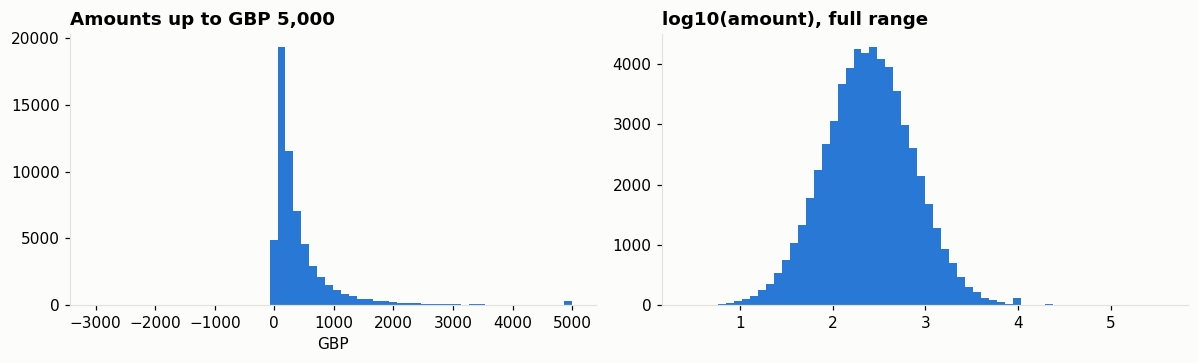

In [7]:
print(df.amount.describe(percentiles=[.5, .9, .99, .999]).round(2).to_string())
print(f"\nabove GBP 50,000: {(df.amount > 50_000).sum()}")
print(f"largest: GBP {df.amount.max():,.2f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].hist(df.amount.clip(upper=5000).dropna(), bins=60, color=S1)
axes[0].set_title("Amounts up to GBP 5,000", loc="left"); axes[0].set_xlabel("GBP")
axes[1].hist(np.log10(df.amount[df.amount > 0].dropna()), bins=60, color=S1)
axes[1].set_title("log10(amount), full range", loc="left")
plt.tight_layout(); plt.show()

The five transactions above GBP 50,000 sit against a median of GBP 245.
Standard practice would winsorise. **In AML that deletes the thing you are
looking for**, so they are kept uncapped.

## Mixed timestamp formats

In [8]:
slash = df.timestamp.str.contains("/", na=False)
print(f"YYYY-MM-DD HH:MM:SS : {(~slash).sum():,}")
print(f"DD/MM/YYYY HH:MM    : {slash.sum():,}")

first = df.loc[slash, "timestamp"].str.slice(0, 2).astype(int)
print(f"\nfirst component of the slash rows ranges {first.min()}-{first.max()}")
print("values above 12 occur, so it is the DAY, not the month")

YYYY-MM-DD HH:MM:SS : 57,146
DD/MM/YYYY HH:MM    : 3,008

first component of the slash rows ranges 1-31
values above 12 occur, so it is the DAY, not the month


That matters: letting pandas infer the format would read `03/04/2025` as
4 March in some rows and 3 April in others, silently.

## Country name formatting

In [9]:
pd.concat([df.sender_country, df.receiver_country]).value_counts(dropna=False).to_frame("rows")

,rows
Spain,13364
France,13140
Ireland,12510
Netherlands,12309
Canada,12219
Germany,12132
Australia,12029
United States,10430
United Kingdom,9925
Cyprus,1394


Eight spellings of two countries. Any `groupby` or jurisdiction rule would
split one country into several and undercount it.

## The identifier leaks the answer

The transaction reference is supposed to be opaque. It is not.

In [10]:
df.transaction_id.str.slice(0, 4).value_counts().to_frame("rows")

,rows
transaction_id,
TXN0,60014
TXNS,101
TXNR,39


`TXNS` is structuring, `TXNR` is rapid movement: 140 rows, exactly matching the
number of planted cases. **Any feature derived from the ID would score perfectly
and mean nothing.**

There is a second leak in a place nobody would look.

In [11]:
print(df.transaction_type.value_counts().to_frame("rows").to_string())
print()
wire = df[df.transaction_type == "wire_transfer"]
print(f"'wire_transfer' rows: {len(wire)}")
print(f"  all prefixed TXNR : {wire.transaction_id.str.startswith('TXNR').all()}")
print(f"  all UK to UK      : {(wire.sender_country == wire.receiver_country).all()}")

                   rows
transaction_type       
transfer          15235
deposit           14984
withdrawal        14971
payment           14925
wire_transfer        39

'wire_transfer' rows: 39
  all prefixed TXNR : True
  all UK to UK      : False


An undocumented fifth `transaction_type` sitting on precisely the 39
rapid-movement rows. One-hot encoded, that single dummy is a perfect detector of
a planted pattern. Both leaks are neutralised in notebook 02.

## Account behaviour

Useful for calibrating the rules: how active is a typical account?

In [12]:
sent = df.sender_account.value_counts()
print(f"distinct senders: {sent.size:,}")
print(f"transactions sent per account: median {sent.median():.0f}, "
      f"p99 {sent.quantile(.99):.0f}, max {sent.max()}")

distinct senders: 3,000
transactions sent per account: median 20, p99 32, max 43


## The finding that shaped the structuring rule

Textbook structuring is one customer splitting one deposit. Looking at the band
just under GBP 10,000 tells a different story.

In [13]:
band = df[(df.amount >= 9000) & (df.amount < 10000)]
print(f"{len(band)} transactions in the GBP 9,000-9,999 band\n")
print("per RECEIVER (top 6):"); print(band.receiver_account.value_counts().head(6).to_string())
print("\nper SENDER (top 6):"); print(band.sender_account.value_counts().head(6).to_string())

110 transactions in the GBP 9,000-9,999 band

per RECEIVER (top 6):
receiver_account
ACC101506    12
ACC102324    12
ACC101167    11
ACC100205    11
ACC101913    10
ACC100693     8

per SENDER (top 6):
sender_account
ACC101126    5
ACC100862    4
ACC102503    4
ACC102690    4
ACC102013    4
ACC102192    4


Beneficiary accounts take **10 to 12** near-threshold payments each, while no
single sender exceeds 4. That is funnelling (many senders into one account), not
self-structuring.

**A sender-only rule would miss most of the pattern.** The structuring rule in
notebook 03 therefore checks both sides of the transaction. This was visible in
the raw data, without labels.

## A note on the label file

Checked once, for its shape only.

In [14]:
truth = pd.read_csv(config.GROUND_TRUTH)
print(f"rows: {len(truth):,}   distinct ids: {truth.transaction_id.nunique():,}")
print(f"positive ROWS: {truth.is_laundering_pattern.sum()}")
print(f"distinct positive TRANSACTIONS: {truth.drop_duplicates('transaction_id').is_laundering_pattern.sum()}")

rows: 60,154   distinct ids: 60,139
positive ROWS: 140
distinct positive TRANSACTIONS: 139


140 positive rows but **139 distinct positive transactions**: one known case is
among the 15 replays. 139 is the honest denominator. Using 140 would cap
reported recall at 99.3% for no reason.